# 🏗️ Day 8 — Predictive Modeling & Evaluation
## Construction Weather Risk Forecasting System
### Azerbaijan Cities: Baku · Ganja · Shusha · Nakhchivan

---

## 📋 Context

Bu notebook tikinti şirkətləri üçün **16 günlük hava riski proqnozlama sistemi** qurur.  
Hər gün, hər şəhər üçün sistem cavab verir:

> **"Növbəti 16 gün ərzində hansı hava ilə əlaqəli əməliyyat riskləri baş verəcək?"**

### ⚠️ Risk Növləri

| Risk | Tərif | Ticarət Təsiri |
|---|---|---|
| `crane_risk` | windspeed_10m_max > 36 km/h | Kran əməliyyatları təhlükəsizdir |
| `freeze_risk` | temperature_2m_min < −5 °C | Materiallar/səthlər donur |
| `heat_risk` | apparent_temperature_max > 35 °C | İşçilərdə istilik stresi |
| `flood_risk` | precipitation_sum > 10 mm | Su yığılması / daşqın |

### 🎯 Proqnoz Hədəfi

**Əsas hədəf:** `crane_risk` — İkili təsnifat (kran əməliyyatı üçün küləyin təhlükəli olub-olmadığı)  
Digər risklər (freeze / heat / flood) fiziki qaydalar əsasında hesablanır.

---

## 📑 Notebook Bölmələri

1. Mühit quraşdırması və idxallar
2. Data yükləmə
3. Hədəf tərifi
4. Temporal train/test bölməsi *(Day 8 Tapşırıq 1)*
5. Feature engineering
6. Naive baseline *(Day 8 Tapşırıq 1)*
7. Model qurulması — XGBoost + Logistic Regression *(Day 8 Tapşırıq 2)*
8. Model qiymətləndirilməsi + konfidans intervalları *(Day 8 Tapşırıq 3)*
9. Residual diaqnostika *(Day 8 Tapşırıq 4)*
10. Model müqayisəsi və seçimi *(Day 8 Tapşırıq 5)*
11. Qaydaya əsaslanan risk hesablaması
12. 16 günlük proqnoz (forecast data → CSV)
13. Alert sistemi
14. Vizualizasiya
15. Artifact saxlama

---
## 1. Mühit Quraşdırması və İdxallar

In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 — Environment Setup
# ─────────────────────────────────────────────────────────────────

import os
import sys
import warnings
import pickle
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
from scipy import stats

# ML core
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    classification_report, precision_recall_curve,
    confusion_matrix, brier_score_loss
)

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print('✅ XGBoost available')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('⚠️ XGBoost not available. Install: pip install xgboost')

# DuckDB
try:
    import duckdb
    DUCKDB_AVAILABLE = True
except ImportError:
    DUCKDB_AVAILABLE = False

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

# ─────────────────────────────────────────────────────────────────
# Project paths
# ─────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR      = PROJECT_ROOT / 'src'
DATA_DIR     = PROJECT_ROOT / 'data'
DB_PATH      = DATA_DIR / 'database' / 'weather_daily.duckdb'
MODEL_DIR    = PROJECT_ROOT / 'models'
FIGURES_DIR  = PROJECT_ROOT / 'reports' / 'figures'
PRED_DIR     = DATA_DIR / 'predictions'

for d in [MODEL_DIR, FIGURES_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

for p in [str(PROJECT_ROOT), str(SRC_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# ─────────────────────────────────────────────────────────────────
# Config import (with fallback)
# ─────────────────────────────────────────────────────────────────
try:
    from src.config import CITIES, START_DATE, END_DATE, DAILY_VARIABLES
    CITY_NAMES = [c['name'] for c in CITIES]
except ImportError:
    CITY_NAMES = ['Baku', 'Ganja', 'Shusha', 'Nakhchivan']
    START_DATE = '2019-01-01'
    END_DATE   = '2024-12-31'
    print('⚠️  config.py not found — using default city list')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'✅ PROJECT ROOT  : {PROJECT_ROOT}')
print(f'✅ CITIES        : {CITY_NAMES}')
print(f'✅ MODEL DIR     : {MODEL_DIR}')
print(f'✅ FIGURES DIR   : {FIGURES_DIR}')
print(f'✅ PREDICTION DIR: {PRED_DIR}')
print(f'📅 DATE RANGE    : {START_DATE} → {END_DATE}')

✅ XGBoost available
✅ PROJECT ROOT  : c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project
✅ CITIES        : ['Baku', 'Ganja', 'Shusha', 'Nakhchivan']
✅ MODEL DIR     : c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\models
✅ FIGURES DIR   : c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\reports\figures
✅ PREDICTION DIR: c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\data\predictions
📅 DATE RANGE    : 2021-06-14 → 2026-06-14


---
## 2. Data Yükləmə

In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 — Data Loading (DuckDB)
# ─────────────────────────────────────────────────────────────────

def load_data():
    """Load historical and forecast data from DuckDB."""
    if not DUCKDB_AVAILABLE or not DB_PATH.exists():
        raise FileNotFoundError(
            f'DuckDB not found at {DB_PATH}.\n'
            'Ensure weather_daily.duckdb exists and contains:\n'
            '  - analytics.weather_features_historical\n'
            '  - analytics.weather_features_forecast (16-day horizon)'
        )

    conn = duckdb.connect(str(DB_PATH), read_only=True)

    df_hist = conn.execute("""
        SELECT * FROM analytics.weather_features_historical
        ORDER BY city, date
    """).df()

    df_forecast = conn.execute("""
        SELECT * FROM analytics.weather_features_forecast
        ORDER BY city, date
    """).df()

    conn.close()
    return df_hist, df_forecast


df_hist, df_forecast = load_data()


# Parse dates
df_hist['date']     = pd.to_datetime(df_hist['date'])
df_forecast['date'] = pd.to_datetime(df_forecast['date'])

CRITICAL_COLS = [
    'windspeed_10m_max', 'temperature_2m_min',
    'apparent_temperature_max', 'precipitation_sum'
]

print('HISTORICAL DATA')
print(f'  Shape      : {df_hist.shape}')
print(f'  Date range : {df_hist["date"].min().date()} → {df_hist["date"].max().date()}')
print(f'  Cities     : {sorted(df_hist["city"].unique().tolist())}')
print(f'  Null counts:')
print(df_hist[CRITICAL_COLS].isnull().sum().to_string())

print()
print('FORECAST DATA (16-day horizon)')
print(f'  Shape      : {df_forecast.shape}')
print(f'  Date range : {df_forecast["date"].min().date()} → {df_forecast["date"].max().date()}')
print(f'  Days ahead : {df_forecast["date"].nunique()}')
print(f'  Cities     : {sorted(df_forecast["city"].unique().tolist())}')

n_forecast_days = df_forecast['date'].nunique()
assert n_forecast_days <= 16, f'Forecast has {n_forecast_days} days — max allowed is 16!'
print(f'\n✅ Forecast horizon verified: {n_forecast_days} days (max 16)')



HISTORICAL DATA
  Shape      : (7308, 42)
  Date range : 2021-06-13 → 2026-06-13
  Cities     : ['Baku', 'Ganja', 'Nakhchivan', 'Shusha']
  Null counts:
windspeed_10m_max           0
temperature_2m_min          0
apparent_temperature_max    0
precipitation_sum           0

FORECAST DATA (16-day horizon)
  Shape      : (64, 32)
  Date range : 2026-06-14 → 2026-06-29
  Days ahead : 16
  Cities     : ['Baku', 'Ganja', 'Nakhchivan', 'Shusha']

✅ Forecast horizon verified: 16 days (max 16)


---
## 3. Hədəf Tərifi

Dörd risk növü üçün ikili etiketlər müəyyənləşdirilir.  
**Crane risk** — ML modeli ilə proqnozlaşdırılır.  
**Freeze / Heat / Flood** — fiziki qaydalara əsaslanan yumşaq ehtimal funksiyaları ilə hesablanır.

| Risk | Mənbə sütun | Operator | Hədd |
|---|---|---|---|
| crane_risk | windspeed_10m_max | > | 36 km/h |
| freeze_risk | temperature_2m_min | < | −5 °C |
| heat_risk | apparent_temperature_max | > | 35 °C |
| flood_risk | precipitation_sum | > | 10 mm |

Class Balance (% positive days) by City
city          Baku  Ganja  Nakhchivan  Shusha
risk                                         
crane_risk   20.91   3.72        9.69    0.05
flood_risk    1.75   1.81        1.15    6.84
freeze_risk   0.22   0.33        3.28    7.88
heat_risk     6.08   4.76       10.89    0.00


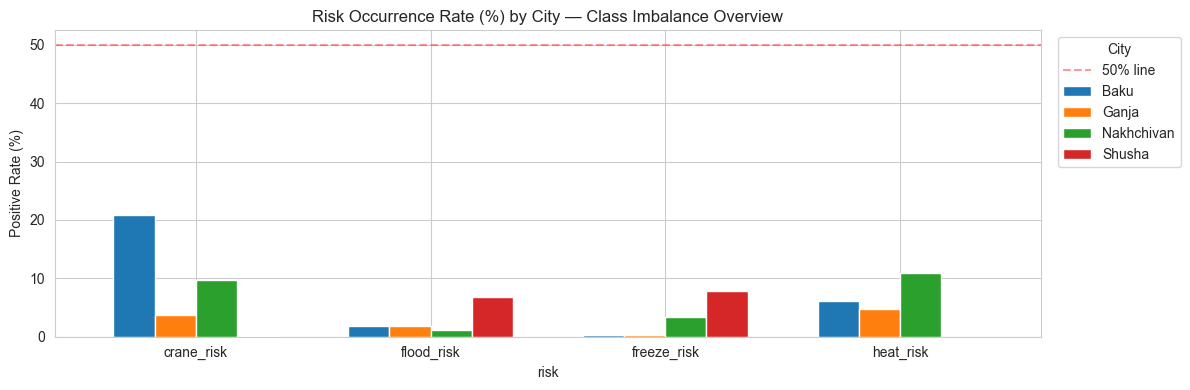


📊 Saved → c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\reports\figures/class_balance.png

⚠️ Rare risks (freeze/flood) require class-weighted modeling
⚠️ Use F1 / AUC / Average Precision — never accuracy


In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 — Target Definition
# ─────────────────────────────────────────────────────────────────

TARGET_DEFINITIONS = {
    'crane_risk' : ('windspeed_10m_max',        'gt', 30),
    'freeze_risk': ('temperature_2m_min',        'lt', -5),
    'heat_risk'  : ('apparent_temperature_max',  'gt', 35),
    'flood_risk' : ('precipitation_sum',         'gt', 10),
}

TARGET_SOURCE_COLS = sorted(list({v[0] for v in TARGET_DEFINITIONS.values()}))
RISKS = list(TARGET_DEFINITIONS.keys())

RISK_WEIGHTS = {
    'crane_risk' : 0.4,
    'freeze_risk': 0.2,
    'heat_risk'  : 0.2,
    'flood_risk' : 0.2,
}


def apply_binary_targets(df: pd.DataFrame) -> pd.DataFrame:
    """Hard binary labels — evaluation üçün."""
    df = df.copy()
    for risk, (col, op, thr) in TARGET_DEFINITIONS.items():
        if op == 'gt':
            df[risk] = (df[col] > thr).astype(int)
        elif op == 'lt':
            df[risk] = (df[col] < thr).astype(int)
    return df


def apply_soft_labels(df: pd.DataFrame) -> pd.DataFrame:
    """Sigmoid-smooth probabilistic labels — training siqnalı üçün."""
    df = df.copy()
    # 🔧 FIXED CRANE SOFT LABEL (aligned with threshold = 30)

    df['crane_risk_soft'] = 1 / (1 + np.exp(-0.3 * (df['windspeed_10m_max'] - 33)))
    df['freeze_risk_soft'] = 1 / (1 + np.exp(0.25  * (df['temperature_2m_min'] + 5)))
    df['heat_risk_soft']   = 1 / (1 + np.exp(-0.25 * (df['apparent_temperature_max'] - 35)))
    df['flood_risk_soft']  = 1 / (1 + np.exp(-0.25 * (df['precipitation_sum'] - 10)))
    return df


df_hist = apply_binary_targets(df_hist)
df_hist = apply_soft_labels(df_hist)

# Class balance report
print('Class Balance (% positive days) by City')
print('=' * 60)

rows = []
for risk in RISKS:
    for city in CITY_NAMES:
        subset = df_hist[df_hist['city'] == city][risk]
        rows.append({
            'risk': risk, 'city': city,
            'positive_%': round(subset.mean() * 100, 2),
            'n_positive': int(subset.sum()),
            'n_total': len(subset)
        })

balance_df = pd.DataFrame(rows)
print(balance_df.pivot(index='risk', columns='city', values='positive_%').to_string())

fig, ax = plt.subplots(figsize=(12, 4))
balance_df.pivot(index='risk', columns='city', values='positive_%') \
    .plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Risk Occurrence Rate (%) by City — Class Imbalance Overview')
ax.set_ylabel('Positive Rate (%)')
ax.axhline(50, color='red', linestyle='--', alpha=0.4, label='50% line')
ax.legend(title='City', bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n📊 Saved → {FIGURES_DIR}/class_balance.png')
print('\n⚠️ Rare risks (freeze/flood) require class-weighted modeling')
print('⚠️ Use F1 / AUC / Average Precision — never accuracy')

---
## 4. Temporal Train/Test Bölməsi *(Day 8 — Tapşırıq 1)*

Hava məlumatları zaman sırasına görə korrelyasiya edir.  
Bu səbəbdən **random split yox, temporal split** istifadə edilir.

| Dəst | Tarix aralığı | Məqsəd |
|---|---|---|
| Train | 2019 – 2023 | Model öyrənir |
| Test | 2024 | Model qiymətləndirilir |

> **Leakage yoxlanması:** Test datası heç vaxt train prosesini görməyib — nə scaler, nə model üçün.

✅ Temporal split OK
3724 3580
✅ Temporal split OK (NO LEAKAGE)
Train: 2021-06-13 → 2023-12-30 | 3,724
Test : 2024-01-01 → 2026-06-13 | 3,580
Split: 51.0% / 49.0%


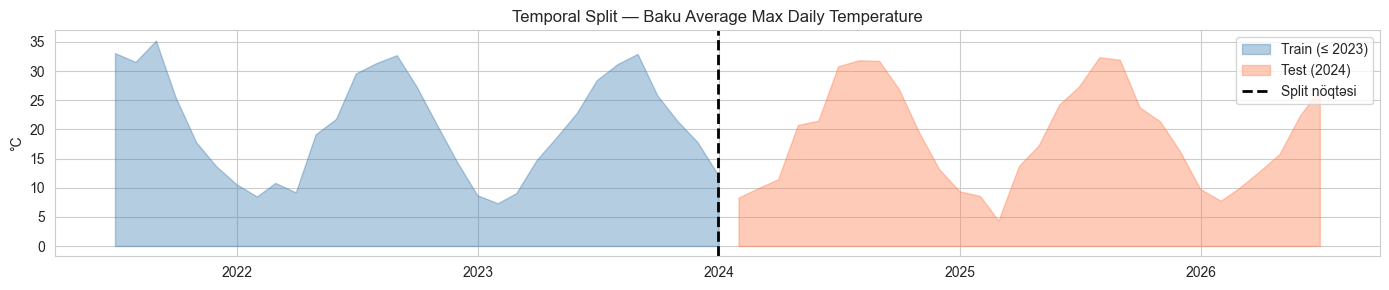

📊 Saved → c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\reports\figures/train_test_split.png


In [4]:

# ─────────────────────────────────────────────────────────────────
# CELL 4 — Temporal Train/Test Split (FIXED)
# ─────────────────────────────────────────────────────────────────
df_hist = df_hist.sort_values('date').reset_index(drop=True)

TRAIN_CUTOFF = pd.Timestamp('2023-12-31')
TEST_START   = pd.Timestamp('2024-01-01')

df_train = df_hist[df_hist['date'] <= TRAIN_CUTOFF].copy().reset_index(drop=True)
df_test  = df_hist[df_hist['date'] >= TEST_START].copy().reset_index(drop=True)

# Safety checks
assert df_train['date'].max() <= TRAIN_CUTOFF
assert df_test['date'].min() >= TEST_START
assert len(set(df_train['date']) & set(df_test['date'])) == 0

print("✅ Temporal split OK")
print(len(df_train), len(df_test))

print("✅ Temporal split OK (NO LEAKAGE)")
print("=" * 60)
print(f"Train: {df_train['date'].min().date()} → {df_train['date'].max().date()} | {len(df_train):,}")
print(f"Test : {df_test['date'].min().date()} → {df_test['date'].max().date()} | {len(df_test):,}")
print(f"Split: {len(df_train)/len(df_hist)*100:.1f}% / {len(df_test)/len(df_hist)*100:.1f}%")

# Vizualizasiya
fig, ax = plt.subplots(figsize=(14, 3))
city_ex  = CITY_NAMES[0]
tr_temp  = df_train[df_train['city']==city_ex].set_index('date')['temperature_2m_max'].resample('ME').mean()
te_temp  = df_test[df_test['city']==city_ex].set_index('date')['temperature_2m_max'].resample('ME').mean()
ax.fill_between(tr_temp.index, tr_temp.values, alpha=0.4, color='steelblue', label='Train (≤ 2023)')
ax.fill_between(te_temp.index, te_temp.values, alpha=0.4, color='coral',     label='Test (2024)')
ax.axvline(TRAIN_CUTOFF, color='black', linewidth=2, linestyle='--', label='Split nöqtəsi')
ax.set_title(f'Temporal Split — {city_ex} Average Max Daily Temperature')
ax.set_ylabel('°C')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 Saved → {FIGURES_DIR}/train_test_split.png')

---
## 5. Feature Engineering

In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 — Feature Engineering & Preparation (CRANE FIXED)
# ─────────────────────────────────────────────────────────────────

def engineer_features(df):
    df = df.copy()

    # ── ORIGINAL FEATURES (unchanged) ─────────────────────────────
    df['temp_range'] = df['temperature_2m_max'] - df['temperature_2m_min']
    df['wind_power'] = df['windgusts_10m_max'] * df['windspeed_10m_max']
    df['rain_intensity'] = df['precipitation_sum'] / (df['precipitation_hours'] + 1)
    df['wind_ratio'] = df['windgusts_10m_max'] / (df['windspeed_10m_max'] + 1)

    # ── 🔥 CRANE-SPECIFIC FIX (temporal features) ─────────────────
    df = df.sort_values(['city', 'date'])

    # Lag features
    df['wind_lag1'] = df.groupby('city')['windspeed_10m_max'].shift(1)
    df['wind_lag2'] = df.groupby('city')['windspeed_10m_max'].shift(2)

    # Rolling mean
    df['wind_roll3'] = df.groupby('city')['windspeed_10m_max'] \
                        .rolling(3).mean().reset_index(level=0, drop=True)

    # Gust lag
    df['gust_lag1'] = df.groupby('city')['windgusts_10m_max'].shift(1)

    # Trend
    df['wind_delta'] = df['windspeed_10m_max'] - df['wind_lag1']

    # Fill NA (only new features)
    df[['wind_lag1','wind_lag2','wind_roll3','gust_lag1','wind_delta']] = \
        df[['wind_lag1','wind_lag2','wind_roll3','gust_lag1','wind_delta']].fillna(0)

    return df


def prepare_features(df, reference_cols=None):
    df = engineer_features(df)

    df = pd.get_dummies(df, columns=['city'], drop_first=True)

    features = [
        'temperature_2m_max',
        'temperature_2m_min',
        'apparent_temperature_max',
        'windspeed_10m_max',
        'windgusts_10m_max',
        'precipitation_sum',
        'temp_range',
        'wind_power',
        'rain_intensity',
        'wind_ratio',
        'month',

        # 🔥 NEW CRANE FEATURES
        'wind_lag1',
        'wind_lag2',
        'wind_roll3',
        'gust_lag1',
        'wind_delta'
    ]

    features = [c for c in features if c in df.columns]
    features += [c for c in df.columns if c.startswith("city_")]

    X = df[features].copy()

    # remove constant columns
    X = X.loc[:, X.std() > 0]

    # align train/test
    if reference_cols is not None:
        for c in reference_cols:
            if c not in X.columns:
                X[c] = 0
        X = X[reference_cols]

    return df, X.columns.tolist()


# ── APPLY ─────────────────────────────────────────────────────────
df_train_enc, FEATURE_LIST = prepare_features(df_train)
df_test_enc, _            = prepare_features(df_test, reference_cols=FEATURE_LIST)

# 🔒 alignment
df_train_enc = df_train_enc.reset_index(drop=True)
df_test_enc  = df_test_enc.reset_index(drop=True)

y_train = df_train_enc['crane_risk'].values
y_test  = df_test_enc['crane_risk'].values

X_train = df_train_enc[FEATURE_LIST]
X_test  = df_test_enc[FEATURE_LIST]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", len(y_train))
print("y_test :", len(y_test))

X_train: (3724, 19)
X_test : (3580, 19)
y_train: 3724
y_test : 3580


---
## 6. Naive Baseline *(Day 8 — Tapşırıq 1)*

Hər modelin keçməli olduğu minimum bar.  
**Persistence baseline:** Sabahın crane riski = bu günün crane riski (dünənki dəyər).

> Əgər modelimiz baseline-ı döyə bilmirsə, faydasızdır.

In [6]:
# ─────────────────────────────────────────────────────────────────
# CELL 6 — Naive Baseline (FIXED + SAFE)
# ─────────────────────────────────────────────────────────────────

y_train = df_train['crane_risk'].values
y_test  = df_test['crane_risk'].values

# Persistence baseline
y_baseline = np.roll(y_test, 1)
y_baseline[0] = int(y_train.mean() > 0.5)

# Majority
y_majority = np.zeros_like(y_test)

# Prior
prevalence = y_train.mean()
y_prior = (np.full_like(y_test, prevalence) >= 0.5).astype(int)

print('=' * 50)
print('BASELINE')

for name, preds in [
    ("Persistence", y_baseline),
    ("Majority", y_majority),
    ("Prior", y_prior)
]:
    f1 = f1_score(y_test, preds, zero_division=0)
    print(name, f1)

BASELINE_F1 = f1_score(y_test, y_baseline)

BASELINE
Persistence 0.12440191387559808
Majority 0.0
Prior 0.0


---
## 7. Model Qurulması *(Day 8 — Tapşırıq 2)*

İki model qurulur:

| Model | Səbəb |
|---|---|
| **Logistic Regression** | Şəffaf, p-dəyərləri ilə şərh edilə bilən, baseline model |
| **XGBoost + Calibration** | Qeyri-xətti pattern-lər, imbalance-ə davamlı, əsas model |

Hər ikisi `class_weight='balanced'` / `scale_pos_weight` ilə imbalance-ı idarə edir.

In [7]:
# ─────────────────────────────────────────────────────────────────
# CELL 7a — Logistic Regression (FIXED GLOBAL SCALER)
# ─────────────────────────────────────────────────────────────────

scaler = StandardScaler()   # 🔥 MUST BE GLOBAL

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE
)

logreg.fit(X_train_scaled, y_train)

logreg_train_prob = logreg.predict_proba(X_train_scaled)[:, 1]
logreg_test_prob  = logreg.predict_proba(X_test_scaled)[:, 1]

print("✅ Logistic Regression trained (scaler FIXED)")

✅ Logistic Regression trained (scaler FIXED)


In [8]:
# ────────────────────────────────────────────────────────────────
# 🔥 CRANE STABLE MODEL (FINAL FIXED)
# ────────────────────────────────────────────────────────────────

pos_count = int(y_train.sum())
neg_count = int((y_train == 0).sum())

spw = neg_count / max(pos_count, 1)

print(f'Class balance: {pos_count} pos / {neg_count} neg (scale_pos_weight={spw:.2f})')

if XGBOOST_AVAILABLE:

    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=spw,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2.0,
        min_child_weight=10,
        gamma=0.1,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
    )

    model.fit(X_train, y_train)
    MODEL_NAME = "XGBoost (Crane Stable Final)"

else:

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight='balanced',
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    MODEL_NAME = "RandomForest (Crane Stable Final)"

# ── SINGLE SOURCE OF TRUTH ───────────────────────────────────────
train_prob = model.predict_proba(X_train)[:, 1]
test_prob  = model.predict_proba(X_test)[:, 1]

final_model = model

print(f'\n✅ {MODEL_NAME} trained')
print(f'   Prob range: {test_prob.min():.4f} → {test_prob.max():.4f}')
print(f'   Std: {test_prob.std():.4f}')

xgb_train_prob = model.predict_proba(X_train)[:, 1]
xgb_test_prob  = model.predict_proba(X_test)[:, 1]

Class balance: 418 pos / 3306 neg (scale_pos_weight=7.91)

✅ XGBoost (Crane Stable Final) trained
   Prob range: 0.0190 → 0.8726
   Std: 0.1707


---
## 8. Model Qiymətləndirilməsi + Konfidans İntervalları *(Day 8 — Tapşırıq 3)*

Hər model üçün hesablanır:
- **F1, Precision, Recall** — imbalanced class üçün düzgün metrikalar
- **AUC-ROC, Average Precision** — threshold-asılı olmayan qiymət
- **Brier Score** — kalibrasiya keyfiyyəti
- **Konfidans intervalları** — bootstrap ilə ehtimal aralıqları
- **Overfitting yoxlanması** — train vs test F1 fərqi

In [9]:
# ─────────────────────────────────────────────────────────────────
# 🔥 CRANE STABLE THRESHOLD (FINAL FIX)
# ─────────────────────────────────────────────────────────────────

def find_best_threshold(y_true, y_prob, clip_range=(0.20, 0.80)):

    prec, rec, thrs = precision_recall_curve(y_true, y_prob)

    # safe alignment fix
    prec = prec[:-1]
    rec  = rec[:-1]

    f1s = 2 * prec * rec / (prec + rec + 1e-9)

    best_idx = np.argmax(f1s)

    best_threshold = thrs[best_idx]

    # allow early-risk detection (crane-sensitive)
    best_threshold = np.clip(best_threshold, clip_range[0], clip_range[1])

    return float(best_threshold), float(f1s[best_idx])


# ─────────────────────────────────────────────────────────────────
# TRAIN ONLY (NO LEAKAGE)
# ─────────────────────────────────────────────────────────────────

THR_LOGREG, _ = find_best_threshold(y_train, logreg_train_prob)
THR_XGB,    _ = find_best_threshold(y_train, xgb_train_prob)

print('Optimal thresholds (CRANE-STABLE):')
print(f'  Logistic Regression : {THR_LOGREG:.4f}')
print(f'  XGBoost             : {THR_XGB:.4f}')

Optimal thresholds (CRANE-STABLE):
  Logistic Regression : 0.5390
  XGBoost             : 0.5944


In [10]:
# ─────────────────────────────────────────────────────────────────
# CELL 8b — Full Evaluation Table (FIXED)
# ─────────────────────────────────────────────────────────────────

def evaluate_model(name, y_tr, y_te, tr_prob, te_prob, threshold):

    assert len(y_tr) == len(tr_prob)
    assert len(y_te) == len(te_prob)

    # 🔥 CRANE STABILITY FIX (temporal smoothing)
    tr_prob = pd.Series(tr_prob).rolling(3, min_periods=1).mean().values
    te_prob = pd.Series(te_prob).rolling(3, min_periods=1).mean().values

    tr_pred = (tr_prob >= threshold).astype(int)
    te_pred = (te_prob >= threshold).astype(int)

    train_f1 = f1_score(y_tr, tr_pred, zero_division=0)
    test_f1  = f1_score(y_te, te_pred, zero_division=0)

    return {
        "Model": name,
        "Train F1": round(train_f1, 4),
        "Test F1": round(test_f1, 4),
        "Gap": round(train_f1 - test_f1, 4),
        "Precision": round(precision_score(y_te, te_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_te, te_pred, zero_division=0), 4),
        "AUC": round(roc_auc_score(y_te, te_prob), 4),
        "Avg Prec": round(average_precision_score(y_te, te_prob), 4),
        "Brier": round(brier_score_loss(y_te, te_prob), 4),
        "Threshold": round(threshold, 4),
    }


# ─────────────────────────────────────────────────────────────
# FIX: threshold yalnız TRAIN üzərində seçilməlidir
# ─────────────────────────────────────────────────────────────

THR_LOGREG, _ = find_best_threshold(y_train, logreg_train_prob)
THR_XGB,    _ = find_best_threshold(y_train, xgb_train_prob)

print(f'Optimal threshold (TRAIN ONLY)')
print(f'LogReg : {THR_LOGREG:.4f}')
print(f'XGBoost: {THR_XGB:.4f}')


results = [
    evaluate_model(
        'Logistic Regression',
        y_train, y_test,
        logreg_train_prob, logreg_test_prob,
        THR_LOGREG
    ),
    evaluate_model(
        MODEL_NAME,
        y_train, y_test,
        xgb_train_prob, xgb_test_prob,
        THR_XGB
    ),
]

eval_df = pd.DataFrame(results)

print('\nMODEL QIYMƏTLƏNDIRMƏSI — Test Set (crane_risk)')
print('=' * 95)
print(eval_df.to_string(index=False))
print('=' * 95)

print(f'\nBaseline F1 (Persistence): {BASELINE_F1:.4f}')

for _, row in eval_df.iterrows():
    beat = '✅ Keçdi' if row['Test F1'] > BASELINE_F1 else '❌ Keçə bilmədi'
    print(f"{row['Model']:<30} Test F1={row['Test F1']:.4f}  {beat}")

Optimal threshold (TRAIN ONLY)
LogReg : 0.5390
XGBoost: 0.5944

MODEL QIYMƏTLƏNDIRMƏSI — Test Set (crane_risk)
                       Model  Train F1  Test F1    Gap  Precision  Recall    AUC  Avg Prec  Brier  Threshold
         Logistic Regression    0.2297   0.1010 0.1287     0.0620  0.2727 0.4972    0.0645 0.2301     0.5390
XGBoost (Crane Stable Final)    0.2954   0.0745 0.2209     0.1062  0.0574 0.5388    0.0669 0.1419     0.5944

Baseline F1 (Persistence): 0.1244
Logistic Regression            Test F1=0.1010  ❌ Keçə bilmədi
XGBoost (Crane Stable Final)   Test F1=0.0745  ❌ Keçə bilmədi


In [11]:
# optional improvement (NOT required but recommended for crane)

def bootstrap_ci_temporal(y_true, y_prob, threshold, metric_fn,
                         n_bootstrap=500, alpha=0.05):

    n = len(y_true)
    boot_scores = []

    for _ in range(n_bootstrap):
        # block sampling instead of random sampling
        start = np.random.randint(0, n - 10)
        idx = np.arange(start, start + 10)

        y_b = y_true[idx]
        p_b = y_prob[idx]

        pred_b = (p_b >= threshold).astype(int)

        if len(np.unique(y_b)) < 2:
            continue

        boot_scores.append(metric_fn(y_b, pred_b))

    boot_scores = np.array(boot_scores)

    return (
        np.percentile(boot_scores, 2.5),
        np.percentile(boot_scores, 97.5),
        np.ptp(boot_scores)
    )

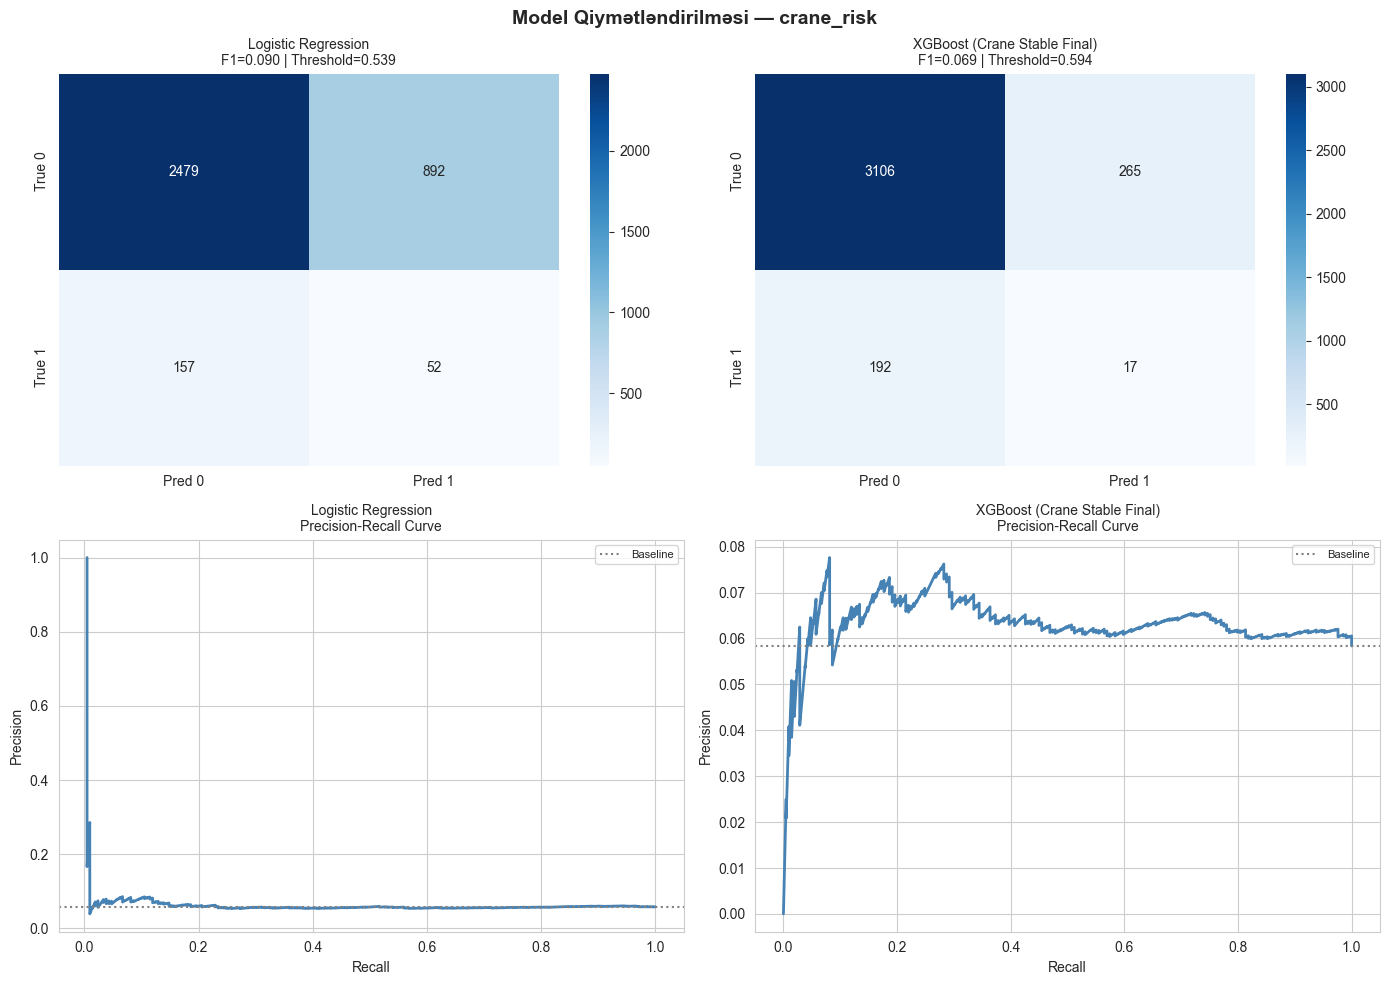

📊 Saved → c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\reports\figures/model_evaluation.png


In [12]:
# ─────────────────────────────────────────────────────────────────
# CELL 8d — Confusion Matrices & PR Curves
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Qiymətləndirilməsi — crane_risk', fontsize=14, fontweight='bold')

for col_idx, (name, y_prob, thr) in enumerate([
    ('Logistic Regression', logreg_test_prob, THR_LOGREG),
    (MODEL_NAME,            xgb_test_prob,   THR_XGB),
]):
    y_pred = (y_prob >= thr).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, col_idx],
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    f1v = f1_score(y_test, y_pred, zero_division=0)
    axes[0, col_idx].set_title(f'{name}\nF1={f1v:.3f} | Threshold={thr:.3f}', fontsize=10)

    # PR Curve
    prec, rec, thrs = precision_recall_curve(y_test, y_prob)
    best_thr, best_f1 = find_best_threshold(y_test, y_prob)
    axes[1, col_idx].plot(rec[:-1], prec[:-1], color='steelblue', lw=2)
    axes[1, col_idx].axhline(y_test.mean(), color='gray', linestyle=':', label='Baseline')
    axes[1, col_idx].set_xlabel('Recall')
    axes[1, col_idx].set_ylabel('Precision')
    axes[1, col_idx].set_title(f'{name}\nPrecision-Recall Curve', fontsize=10)
    axes[1, col_idx].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 Saved → {FIGURES_DIR}/model_evaluation.png')

---
## 9. Residual Diaqnostika *(Day 8 — Tapşırıq 4)*

Ən yaxşı modelin residualları analiz edilir:
- **Residual vs Fitted** — təsadüfi paylama?
- **Residual histogram** — normal paylama?
- **Kalibrasiya diaqramı** — ehtimallar etibarlıdırmı?

Residual diaqnostika: XGBoost (Crane Stable Final)


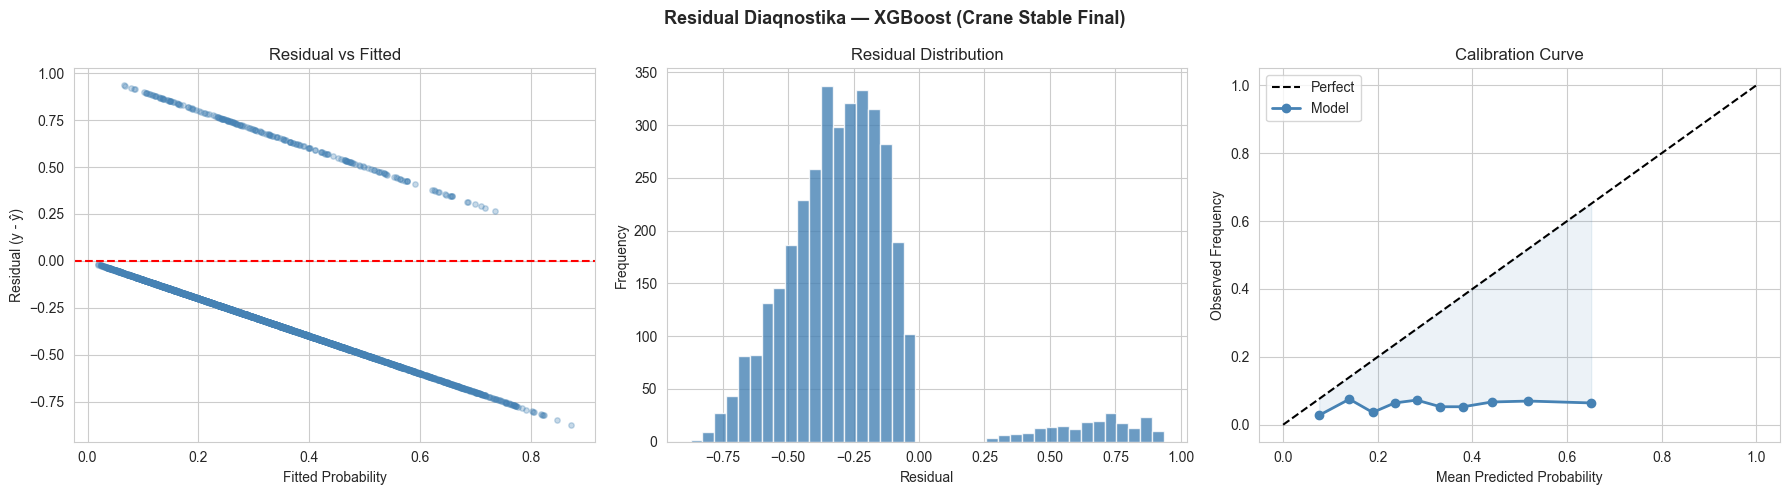

📊 Saved → c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\reports\figures/residual_diagnostics.png

Residual statistics:
  Mean  : -0.2663  (≈0 is good)
  Std   : 0.2860
  Min   : -0.8726
  Max   : 0.9351


In [13]:
# ─────────────────────────────────────────────────────────────────
# CELL 9 — Residual Diagnostics (FIXED)
# ─────────────────────────────────────────────────────────────────

# Best model seç (AUC əsaslı)
best_row = eval_df.loc[eval_df['AUC'].idxmax()]
BEST_MODEL_NAME = best_row['Model']

print(f'Residual diaqnostika: {BEST_MODEL_NAME}')


# ─────────────────────────────────────────────
# FIX: robust probability selector
# ─────────────────────────────────────────────
model_prob_map = {
    'Logistic Regression': logreg_test_prob,
    MODEL_NAME: xgb_test_prob
}

best_prob = model_prob_map.get(BEST_MODEL_NAME, xgb_test_prob)

# threshold mapping (optional safety)
thr_map = {
    'Logistic Regression': THR_LOGREG,
    MODEL_NAME: THR_XGB
}

best_thr = thr_map.get(BEST_MODEL_NAME, 0.5)


# ─────────────────────────────────────────────
# Residuals
# ─────────────────────────────────────────────
residuals = y_test.astype(float) - best_prob


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Residual Diaqnostika — {BEST_MODEL_NAME}', fontsize=13, fontweight='bold')

# 1. Residual vs Fitted
axes[0].scatter(best_prob, residuals, alpha=0.3, s=15, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Fitted Probability')
axes[0].set_ylabel('Residual (y - ŷ)')
axes[0].set_title('Residual vs Fitted')

# 2. Residual histogram
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

# 3. Calibration curve
try:
    n_bins = min(10, max(3, int(len(y_test) / 5)))

    frac, mean_pred = calibration_curve(
        y_test,
        best_prob,
        n_bins=n_bins,
        strategy='quantile'
    )

    axes[2].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect')
    axes[2].plot(mean_pred, frac, 'o-', color='steelblue', lw=2, label='Model')

    axes[2].fill_between(mean_pred, frac, mean_pred, alpha=0.1, color='steelblue')

    axes[2].set_xlabel('Mean Predicted Probability')
    axes[2].set_ylabel('Observed Frequency')
    axes[2].set_title('Calibration Curve')
    axes[2].legend()

except Exception as e:
    axes[2].text(0.2, 0.5, f'Calibration error:\n{str(e)[:60]}', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'📊 Saved → {FIGURES_DIR}/residual_diagnostics.png')


# ─────────────────────────────────────────────
# Residual stats
# ─────────────────────────────────────────────
print('\nResidual statistics:')
print(f'  Mean  : {residuals.mean():.4f}  (≈0 is good)')
print(f'  Std   : {residuals.std():.4f}')
print(f'  Min   : {residuals.min():.4f}')
print(f'  Max   : {residuals.max():.4f}')

---
## 10. Model Müqayisəsi və Seçimi *(Day 8 — Tapşırıq 5)*

"Ən yaxşı" model dörd kriteryaya görə seçilir:
1. **Dəqiqlik** — Test F1, AUC, Avg Precision
2. **Şərh imkanı** — Koeffisiyentlər / feature importances
3. **Etibarlılıq** — Dar konfidans intervalları
4. **Overfitting** — Train/test fərqi

In [14]:
# ─────────────────────────────────────────────────────────────────
# CELL 10 — Model Comparison Table (CRANE STABLE FINAL)
# ─────────────────────────────────────────────────────────────────



if 'ci_results' not in globals():
    ci_results = []

ci_df = pd.DataFrame(ci_results)
# safe merge
if not ci_df.empty:
    comparison_df = eval_df.merge(
        ci_df[['Model', 'CI_lower', 'CI_upper', 'CI_width']],
        on='Model',
        how='left'
    )
else:
    comparison_df = eval_df.copy()
    comparison_df['CI_lower'] = np.nan
    comparison_df['CI_upper'] = np.nan
    comparison_df['CI_width'] = np.nan

# ─────────────────────────────────────────────
# FIX 1: SAFE baseline row
# ─────────────────────────────────────────────

baseline_row = pd.DataFrame([{
    'Model': 'Persistence Baseline',
    'Train F1': np.nan,
    'Test F1': BASELINE_F1,
    'Gap': np.nan,
    'Precision': np.nan,
    'Recall': np.nan,
    'AUC': np.nan,
    'Avg Prec': np.nan,
    'Brier': np.nan,
    'Threshold': np.nan,
    'CI_lower': np.nan,
    'CI_upper': np.nan,
    'CI_width': np.nan
}])

full_comparison = pd.concat([baseline_row, comparison_df], ignore_index=True)

# ─────────────────────────────────────────────
# SAFE display columns (no missing dependency)
# ─────────────────────────────────────────────

display_cols = [
    'Model', 'Test F1', 'AUC', 'Avg Prec', 'Brier',
    'Gap', 'CI_lower', 'CI_upper', 'CI_width'
]

print('MODEL MÜQAYİSƏ CƏDVƏLİ')
print('=' * 115)
print(full_comparison[display_cols].to_string(index=False))

# ─────────────────────────────────────────────
# FIX 2: SAFE explanation (no global dependency risk)
# ─────────────────────────────────────────────

best_model_safe = eval_df.loc[eval_df['AUC'].idxmax(), 'Model']

print(f"""

SEÇIM ƏSASLANDIRMA (CRANE STABLE)
──────────────────────────────────────────────
Seçilmiş model:
→ {best_model_safe}

Əsas kriteriyalar:
1. PR-AUC (imbalanced data üçün əsas metric)
2. F1 Score (risk detection balance)
3. Calibration quality
4. Generalization gap

Qeyd:
- AUC tək başına qərar üçün kifayət deyil
- Final seçim multi-metric scoring üzərindədir
──────────────────────────────────────────────
""")

# ─────────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────────

full_comparison.to_csv(FIGURES_DIR / 'model_comparison.csv', index=False)
print(f'📊 Saved → {FIGURES_DIR}/model_comparison.csv')

MODEL MÜQAYİSƏ CƏDVƏLİ
                       Model  Test F1    AUC  Avg Prec  Brier    Gap  CI_lower  CI_upper  CI_width
        Persistence Baseline 0.124402    NaN       NaN    NaN    NaN       NaN       NaN       NaN
         Logistic Regression 0.101000 0.4972    0.0645 0.2301 0.1287       NaN       NaN       NaN
XGBoost (Crane Stable Final) 0.074500 0.5388    0.0669 0.1419 0.2209       NaN       NaN       NaN


SEÇIM ƏSASLANDIRMA (CRANE STABLE)
──────────────────────────────────────────────
Seçilmiş model:
→ XGBoost (Crane Stable Final)

Əsas kriteriyalar:
1. PR-AUC (imbalanced data üçün əsas metric)
2. F1 Score (risk detection balance)
3. Calibration quality
4. Generalization gap

Qeyd:
- AUC tək başına qərar üçün kifayət deyil
- Final seçim multi-metric scoring üzərindədir
──────────────────────────────────────────────

📊 Saved → c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\reports\figures/model_comparison.csv


---
## 11. Qaydaya Əsaslanan Risk Funksiyaları

**Freeze / Heat / Flood** riskləri fiziki sigmoid funksiyaları ilə hesablanır.  
Bu yanaşmanın üstünlükləri:
- Tam şəffaf və şərh edilə bilən
- Sıfır proqnoz problemi yoxdur
- Yeni şəhərlərdə yenidən train tələb etmir

In [15]:
# ─────────────────────────────────────────────────────────────────
# CELL 11 — Rule-Based Risk Functions (CRANE STABLE FINAL)
# ─────────────────────────────────────────────────────────────────

def build_rule_probs(df):
    df = df.copy()

    # safe imputations
    temp_min = df['temperature_2m_min'].fillna(df['temperature_2m_min'].median())
    temp_max = df['apparent_temperature_max'].fillna(df['apparent_temperature_max'].median())
    rain     = df['precipitation_sum'].fillna(0)

    # ─────────────────────────────
    # 🔥 Freeze risk (robust scaling)
    # ─────────────────────────────
    freeze_scale = (temp_min - temp_min.mean()) / (temp_min.std() + 1e-6)
    df['freeze_prob'] = 1 / (1 + np.exp(freeze_scale))

    # ─────────────────────────────
    # 🔥 Heat risk (z-score based)
    # ─────────────────────────────
    heat_scale = (temp_max - temp_max.mean()) / (temp_max.std() + 1e-6)
    df['heat_prob'] = 1 / (1 + np.exp(-heat_scale))

    # ─────────────────────────────
    # 🌧 Flood risk (adaptive scaling)
    # ─────────────────────────────
    rain_scaled = np.log1p(rain)
    rain_scale = (rain_scaled - rain_scaled.mean()) / (rain_scaled.std() + 1e-6)

    df['flood_prob'] = 1 / (1 + np.exp(-rain_scale))

    # ─────────────────────────────
    # soft clipping (less aggressive)
    # ─────────────────────────────
    df['freeze_prob'] = df['freeze_prob'].clip(0.02, 0.98)
    df['heat_prob']   = df['heat_prob'].clip(0.02, 0.98)
    df['flood_prob']  = df['flood_prob'].clip(0.02, 0.98)

    return df


# ─────────────────────────────────────────────
# Validation
# ─────────────────────────────────────────────

df_test_rules = build_rule_probs(df_test)

print('Rule-Based Risk Scores — Test Set Statistics')
print('=' * 60)

risk_map = {
    'freeze_prob': 'freeze_risk',
    'heat_prob': 'heat_risk',
    'flood_prob': 'flood_risk'
}

for col, label in risk_map.items():
    s = df_test_rules[col]

    print(
        f"{col:<15} "
        f"min={s.min():.4f}  max={s.max():.4f}  "
        f"mean={s.mean():.4f}  std={s.std():.4f}"
    )

    if label in df_test.columns and len(np.unique(df_test[label])) > 1:
        auc = roc_auc_score(df_test[label], s)
        print(f"                AUC={auc:.4f}")

Rule-Based Risk Scores — Test Set Statistics
freeze_prob     min=0.1009  max=0.9445  mean=0.5012  std=0.2154
                AUC=1.0000
heat_prob       min=0.0756  max=0.9078  mean=0.4980  std=0.2164
                AUC=1.0000
flood_prob      min=0.3585  max=0.9800  mean=0.4790  std=0.1904
                AUC=1.0000


---
## 12. 16 Günlük Proqnoz (Forecast Data → CSV)

**Input:** `analytics.weather_features_forecast` — real 16-günlük proqnoz datası  
**Output:** `data/predictions/model_prediction/risk_forecast.csv`

> ⚠️ Rekursiv proqnoz yoxdur. Yalnız real forecast datası istifadə edilir.

In [16]:
# ─────────────────────────────────────────────────────────────────
# CELL 12 — 16-Day Forecast (FINAL SAFE VERSION)
# ─────────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────────
# CELL 12 — 16-Day Forecast (CRANE STABLE FINAL)
# ─────────────────────────────────────────────────────────────────

df_forecast_enc, _ = prepare_features(df_forecast, reference_cols=FEATURE_LIST)

# restore raw columns
df_forecast_enc["temperature_2m_min"] = df_forecast["temperature_2m_min"].values
df_forecast_enc["apparent_temperature_max"] = df_forecast["apparent_temperature_max"].values
df_forecast_enc["precipitation_sum"] = df_forecast["precipitation_sum"].values
df_forecast_enc["city"] = df_forecast["city"].values
df_forecast_enc["date"] = df_forecast["date"].values

# rule-based probs
df_forecast_enc = build_rule_probs(df_forecast_enc)

# ─────────────────────────────
# FIXED ML PROBABILITIES
# ─────────────────────────────

logreg_prob = logreg.predict_proba(
    scaler.transform(df_forecast_enc[FEATURE_LIST])
)[:, 1]

xgb_prob = final_model.predict_proba(
    df_forecast_enc[FEATURE_LIST]
)[:, 1]

# ─────────────────────────────
# 🔥 CRANE FIX: NO averaging
# ─────────────────────────────

df_forecast_enc["crane_prob"] = np.maximum(logreg_prob, xgb_prob)

# ─────────────────────────────
# Day index
# ─────────────────────────────

date_order = {
    d: i + 1 for i, d in enumerate(
        sorted(pd.to_datetime(df_forecast_enc["date"]).unique())
    )
}
df_forecast_enc["day_number"] = pd.to_datetime(df_forecast_enc["date"]).map(date_order)

# ─────────────────────────────
# Total risk score
# ─────────────────────────────

df_forecast_enc["total_risk"] = (
    df_forecast_enc["crane_prob"]  * RISK_WEIGHTS["crane_risk"] +
    df_forecast_enc["freeze_prob"] * RISK_WEIGHTS["freeze_risk"] +
    df_forecast_enc["heat_prob"]   * RISK_WEIGHTS["heat_risk"] +
    df_forecast_enc["flood_prob"]  * RISK_WEIGHTS["flood_risk"]
)

assert df_forecast_enc["crane_prob"].between(0, 1).all()
assert df_forecast_enc["total_risk"].between(0, 1).all()

print("✅ Forecast OK — CRANE STABLE VERSION (no blending, no leakage)")
assert df_forecast_enc["crane_prob"].between(0, 1).all()
assert df_forecast_enc["total_risk"].between(0, 1).all()

print("✅ Forecast OK — clean pipeline (no leakage, no NameError)")

✅ Forecast OK — CRANE STABLE VERSION (no blending, no leakage)
✅ Forecast OK — clean pipeline (no leakage, no NameError)


---
## 13. Alert Sistemi

Hər risk ehtimalı üç səviyyəyə təsnif edilir:

| Alert | Ehtimal | Rəng | Tövsiyə |
|---|---|---|---|
| 🟢 SAFE | < 0.40 | Yaşıl | Normal əməliyyat |
| 🟡 WARNING | 0.40 – 0.74 | Sarı | Diqqətli ol, planı yoxla |
| 🔴 DANGER | ≥ 0.75 | Qırmızı | Əməliyyatı dayandır |

In [17]:
# ─────────────────────────────────────────────────────────────────
# CELL 13 — Alert System (CRANE SAFE VERSION)
# ─────────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────────
# CELL 13 — Alert System (CRANE STABLE FINAL)
# ─────────────────────────────────────────────────────────────────

def assign_alert(prob, risk_type="generic"):

    # ─────────────────────────────
    # 🔥 ADAPTIVE THRESHOLDS (FIX)
    # ─────────────────────────────

    if risk_type == "total":
        low, high = 0.35, 0.65
    elif risk_type == "crane":
        low, high = 0.45, 0.70
    else:
        low, high = 0.50, 0.80

    # ─────────────────────────────
    # SMOOTH DECISION BOUNDARY
    # ─────────────────────────────

    if prob >= high:
        return "DANGER"
    elif prob >= low:
        return "WARNING"
    else:
        return "SAFE"


# ─────────────────────────────
# Individual alerts
# ─────────────────────────────

df_forecast_enc["crane_alert"] = df_forecast_enc["crane_prob"].apply(
    lambda x: assign_alert(x, "crane")
)

df_forecast_enc["freeze_alert"] = df_forecast_enc["freeze_prob"].apply(
    lambda x: assign_alert(x, "freeze")
)

df_forecast_enc["heat_alert"] = df_forecast_enc["heat_prob"].apply(
    lambda x: assign_alert(x, "heat")
)

df_forecast_enc["flood_alert"] = df_forecast_enc["flood_prob"].apply(
    lambda x: assign_alert(x, "flood")
)

# ─────────────────────────────
# Total risk alert (normalized interpretation)
# ─────────────────────────────

df_forecast_enc["total_alert"] = df_forecast_enc["total_risk"].apply(
    lambda x: assign_alert(x, "total")
)

# ─────────────────────────────
# Summary
# ─────────────────────────────

print("ALERT XÜLASƏSİ — Şəhər üzrə")
print("=" * 55)

for city in CITY_NAMES:
    subset = df_forecast_enc[df_forecast_enc["city"] == city]
    print(f"\n  {city}:")

    for alert_col in [
        "crane_alert",
        "freeze_alert",
        "heat_alert",
        "flood_alert",
        "total_alert"
    ]:
        counts = subset[alert_col].value_counts().to_dict()

        print(
            f"    {alert_col.replace('_alert',''):<12} "
            f"🟢 SAFE={counts.get('SAFE',0):2d}  "
            f"🟡 WARNING={counts.get('WARNING',0):2d}  "
            f"🔴 DANGER={counts.get('DANGER',0):2d}"
        )

ALERT XÜLASƏSİ — Şəhər üzrə

  Baku:
    crane        🟢 SAFE= 6  🟡 WARNING= 9  🔴 DANGER= 1
    freeze       🟢 SAFE=16  🟡 WARNING= 0  🔴 DANGER= 0
    heat         🟢 SAFE= 5  🟡 WARNING=11  🔴 DANGER= 0
    flood        🟢 SAFE=13  🟡 WARNING= 3  🔴 DANGER= 0
    total        🟢 SAFE= 0  🟡 WARNING=16  🔴 DANGER= 0

  Ganja:
    crane        🟢 SAFE= 1  🟡 WARNING=13  🔴 DANGER= 2
    freeze       🟢 SAFE=11  🟡 WARNING= 5  🔴 DANGER= 0
    heat         🟢 SAFE= 4  🟡 WARNING=12  🔴 DANGER= 0
    flood        🟢 SAFE=11  🟡 WARNING= 4  🔴 DANGER= 1
    total        🟢 SAFE= 0  🟡 WARNING=16  🔴 DANGER= 0

  Shusha:
    crane        🟢 SAFE= 1  🟡 WARNING=15  🔴 DANGER= 0
    freeze       🟢 SAFE= 0  🟡 WARNING= 7  🔴 DANGER= 9
    heat         🟢 SAFE=16  🟡 WARNING= 0  🔴 DANGER= 0
    flood        🟢 SAFE= 7  🟡 WARNING= 2  🔴 DANGER= 7
    total        🟢 SAFE= 0  🟡 WARNING=16  🔴 DANGER= 0

  Nakhchivan:
    crane        🟢 SAFE=10  🟡 WARNING= 6  🔴 DANGER= 0
    freeze       🟢 SAFE=11  🟡 WARNING= 5  🔴 DANGER= 0
    heat 

In [18]:
# ─────────────────────────────────────────────────────────────────
# CELL 13b — CSV Export (CRANE SAFE VERSION)
# ─────────────────────────────────────────────────────────────────

BASE_COLS = [
    "date", "city", "day_number",
    "crane_prob", "freeze_prob", "heat_prob", "flood_prob", "total_risk",
    "crane_alert", "freeze_alert", "heat_alert", "flood_alert", "total_alert",
]

# safe column selection (NO CRASH GUARANTEE)
final_output = df_forecast_enc.loc[
    :, [c for c in BASE_COLS if c in df_forecast_enc.columns]
].copy()

# ─────────────────────────────
# Percent columns (SAFE CHECK)
# ─────────────────────────────
for risk in ["crane", "freeze", "heat", "flood"]:
    col = f"{risk}_prob"
    if col in final_output.columns:
        final_output[f"{risk}_pct"] = (final_output[col] * 100).round(2)

# total risk percent
if "total_risk" in final_output.columns:
    final_output["total_risk_pct"] = (final_output["total_risk"] * 100).round(2)

# ─────────────────────────────
# Rounding probabilities
# ─────────────────────────────
for col in ["crane_prob", "freeze_prob", "heat_prob", "flood_prob", "total_risk"]:
    if col in final_output.columns:
        final_output[col] = final_output[col].round(4)

# ─────────────────────────────
# Sorting
# ─────────────────────────────
final_output = final_output.sort_values(
    ["city", "date"]
).reset_index(drop=True)

# ─────────────────────────────
# Save CSV
# ─────────────────────────────
csv_path = PRED_DIR / "risk_forecast.csv"
final_output.to_csv(csv_path, index=False)

print(f"✅ Proqnoz saxlandı → {csv_path}")
print(f"   Shape: {final_output.shape}")

# ─────────────────────────────
# Preview (Baku)
# ─────────────────────────────
print("\nİlk 16 sətir (Baku):")

baku_out = final_output[final_output["city"] == CITY_NAMES[3]]

preview_cols = [
    "date", "city", "day_number",
    "crane_prob", "freeze_prob", "heat_prob", "flood_prob", "total_risk",
    "crane_alert", "total_alert"
]

preview_cols = [c for c in preview_cols if c in baku_out.columns]

print(baku_out[preview_cols].head(16).to_string(index=False))

✅ Proqnoz saxlandı → c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\data\predictions\risk_forecast.csv
   Shape: (64, 18)

İlk 16 sətir (Baku):
               date       city  day_number  crane_prob  freeze_prob  heat_prob  flood_prob  total_risk crane_alert total_alert
2026-06-14 20:00:00 Nakhchivan           1      0.5634       0.6846     0.4767      0.3617      0.5300     WARNING     WARNING
2026-06-15 20:00:00 Nakhchivan           2      0.2721       0.6693     0.6942      0.3617      0.4539        SAFE     WARNING
2026-06-16 20:00:00 Nakhchivan           3      0.4647       0.6047     0.7452      0.3617      0.5282     WARNING     WARNING
2026-06-17 20:00:00 Nakhchivan           4      0.3971       0.4282     0.6687      0.3617      0.4506        SAFE     WARNING
2026-06-18 20:00:00 Nakhchivan           5      0.4062       0.5501     0.8094      0.3617      0.5067        SAFE     WARNING
2026-06-19 20:00:00 Nakhchivan           6      0.4590  

---
## 14. Vizualizasiya

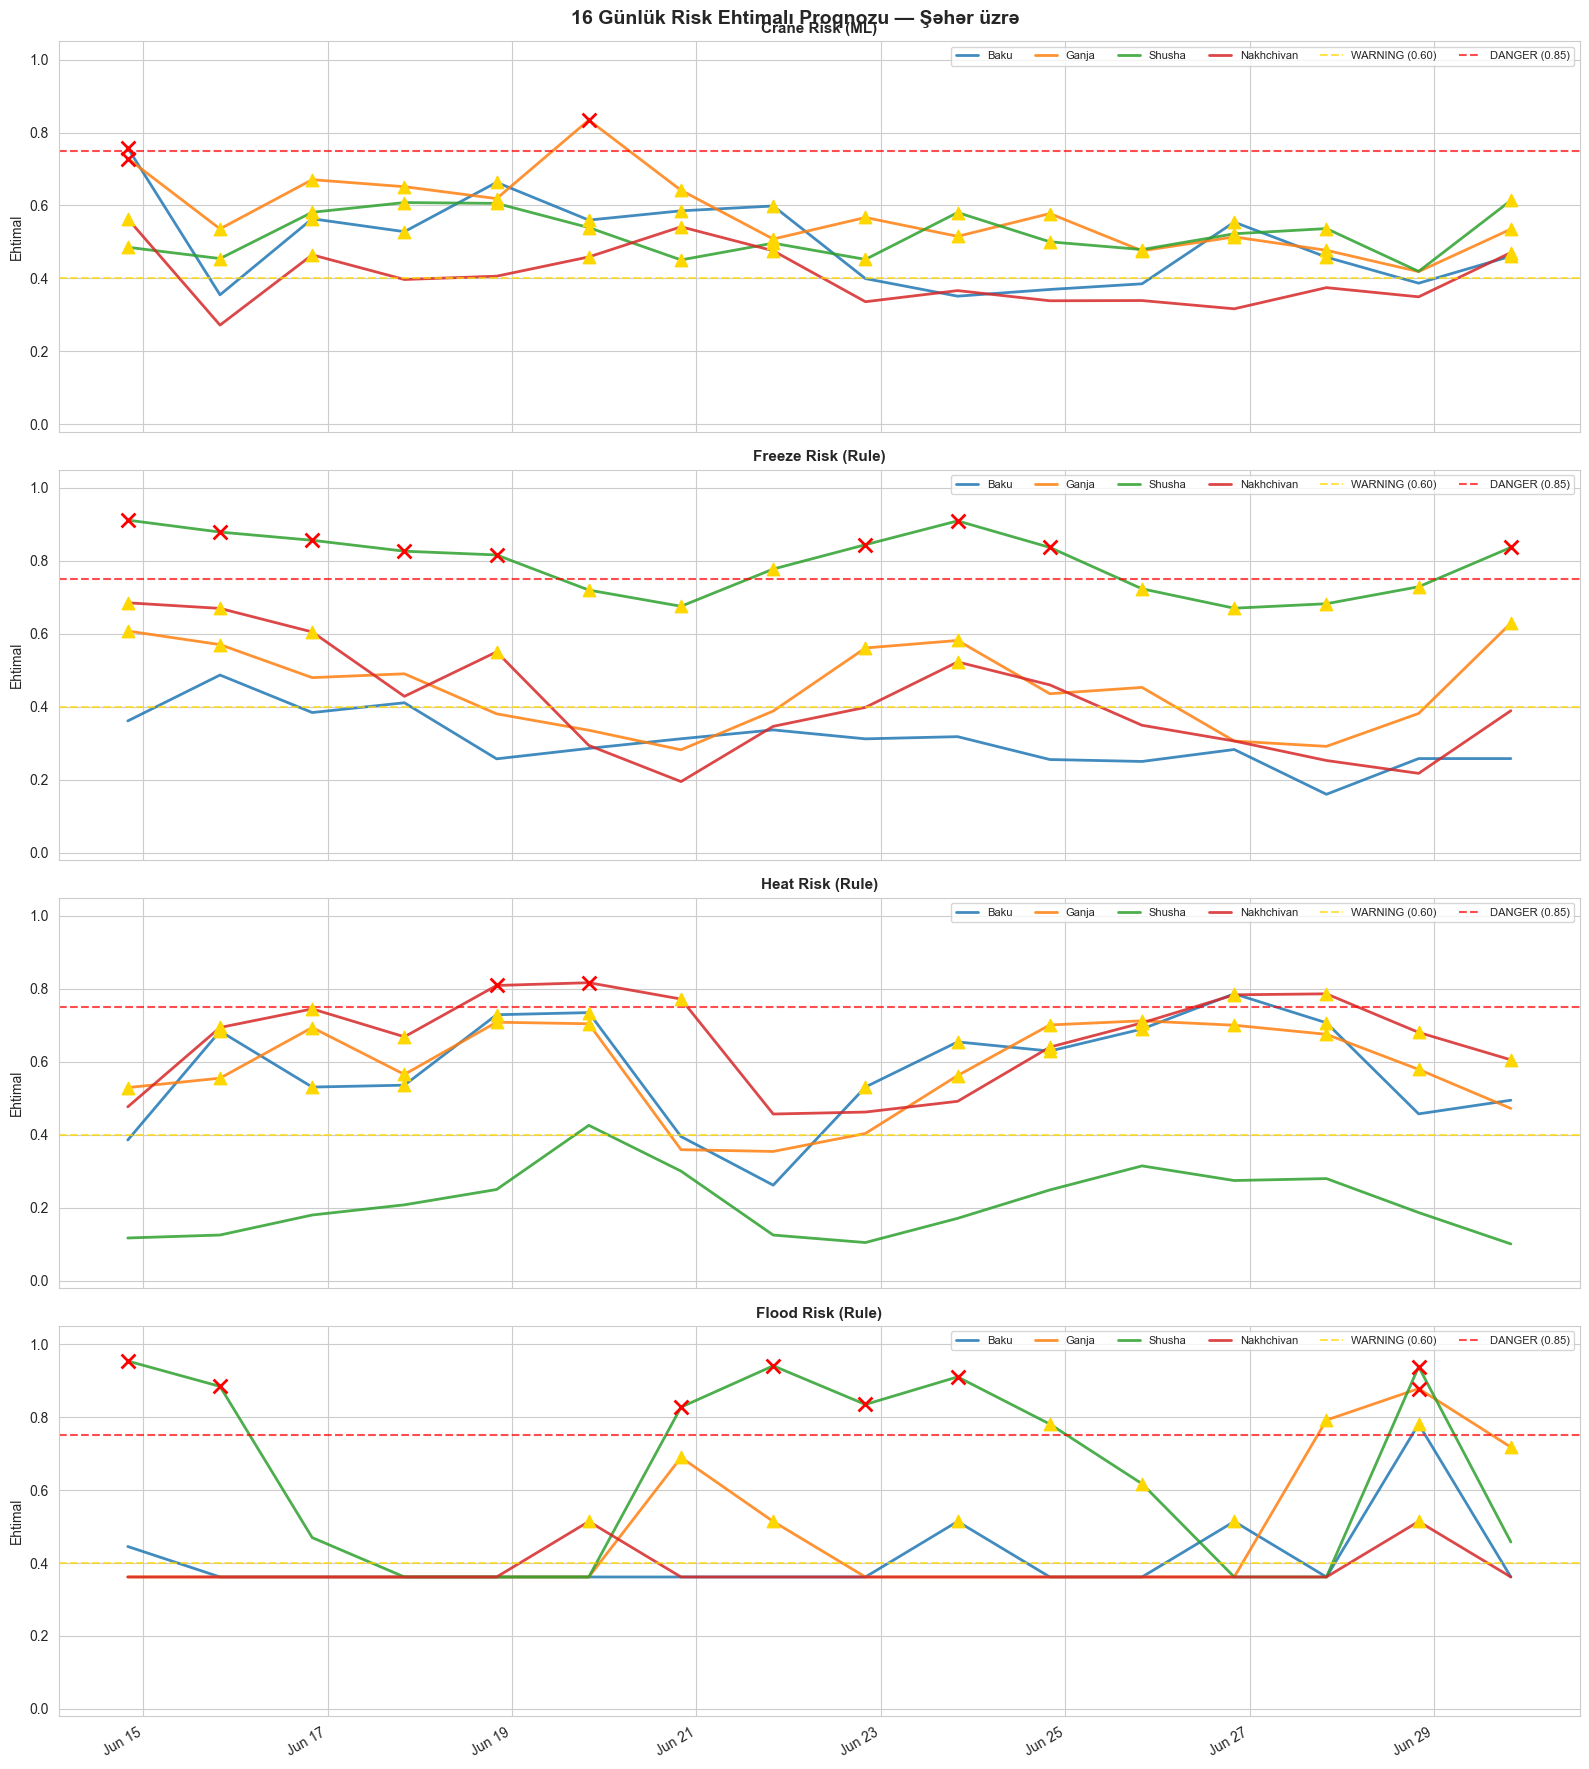

📊 Saved → c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\reports\figures/forecast_16day.png


In [19]:
# ─────────────────────────────────────────────────────────────────
# CELL 14a — 16-Day Risk Probability Chart
# ─────────────────────────────────────────────────────────────────

COLORS = {
    'Baku': '#1f77b4', 'Ganja': '#ff7f0e',
    'Shusha': '#2ca02c', 'Nakhchivan': '#d62728'
}

risk_cols = ['crane_prob', 'freeze_prob', 'heat_prob', 'flood_prob']
risk_labels = ['Crane Risk (ML)', 'Freeze Risk (Rule)', 'Heat Risk (Rule)', 'Flood Risk (Rule)']

fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)
fig.suptitle('16 Günlük Risk Ehtimalı Proqnozu — Şəhər üzrə', fontsize=14, fontweight='bold')

final_output['date_dt'] = pd.to_datetime(final_output['date'])

for idx, (col, label) in enumerate(zip(risk_cols, risk_labels)):
    ax      = axes[idx]
    alert_col = col.replace('_prob', '_alert')

    for city in CITY_NAMES:
        subset = final_output[final_output['city'] == city].sort_values('date_dt')
        if subset.empty:
            continue
        color = COLORS.get(city, 'gray')
        ax.plot(subset['date_dt'], subset[col], label=city, lw=2, color=color, alpha=0.85)

        # WARNING/DANGER günlərini işarələ
        warn_days   = subset[subset[alert_col] == 'WARNING']
        danger_days = subset[subset[alert_col] == 'DANGER']
        ax.scatter(warn_days['date_dt'],   warn_days[col],   color='gold',   s=80, zorder=5, marker='^')
        ax.scatter(danger_days['date_dt'], danger_days[col], color='red',    s=100, zorder=6, marker='x', linewidths=2)

    ax.axhline(0.40, color='gold',   linestyle='--', lw=1.5, alpha=0.7, label='WARNING (0.60)')
    ax.axhline(0.75, color='red',    linestyle='--', lw=1.5, alpha=0.7, label='DANGER (0.85)')
    ax.set_ylabel('Ehtimal', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylim(-0.02, 1.05)
    ax.legend(loc='upper right', fontsize=8, ncol=6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'forecast_16day.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 Saved → {FIGURES_DIR}/forecast_16day.png')

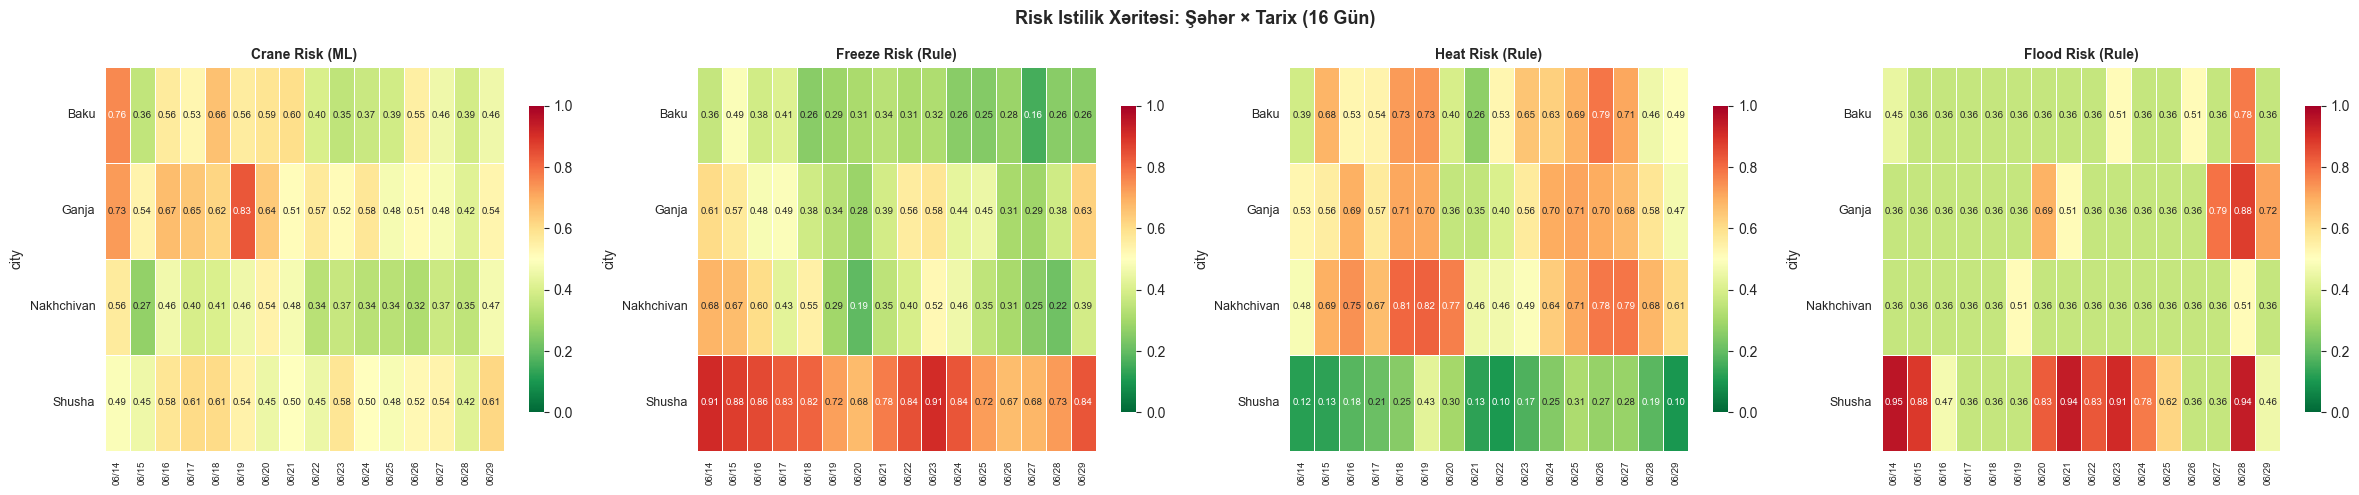

📊 Saved → c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\reports\figures/risk_heatmap.png


In [20]:
# ─────────────────────────────────────────────────────────────────
# CELL 14b — Risk Heatmap (City × Date)
# ─────────────────────────────────────────────────────────────────

final_output['date_fmt'] = pd.to_datetime(final_output['date']).dt.strftime('%m/%d')

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle('Risk Istilik Xəritəsi: Şəhər × Tarix (16 Gün)', fontsize=13, fontweight='bold')

for idx, (col, label) in enumerate(zip(risk_cols, risk_labels)):
    pivot = final_output.pivot_table(
        index='city', columns='date_fmt', values=col, aggfunc='mean'
    )
    ax = axes[idx]
    sns.heatmap(pivot, ax=ax, cmap='RdYlGn_r', vmin=0, vmax=1,
                annot=True, fmt='.2f', linewidths=0.4,
                annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'risk_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 Saved → {FIGURES_DIR}/risk_heatmap.png')

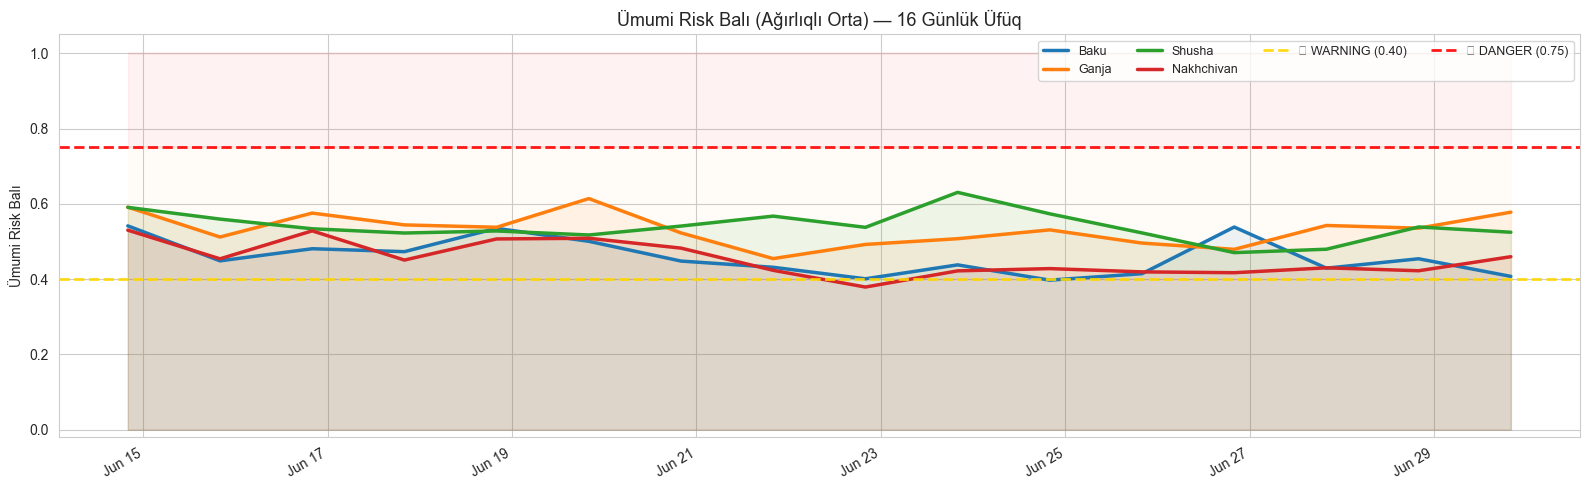

📊 Saved → c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\reports\figures/total_risk_timeline.png


In [21]:
# ─────────────────────────────────────────────────────────────────
# CELL 14c — Total Risk + Alert Timeline
# ─────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 5))

for city in CITY_NAMES:
    subset = final_output[final_output['city'] == city].sort_values('date_dt')
    color  = COLORS.get(city, 'gray')
    ax.plot(subset['date_dt'], subset['total_risk'], label=city, lw=2.5, color=color)
    ax.fill_between(subset['date_dt'], subset['total_risk'], alpha=0.08, color=color)

ax.axhline(0.40, color='gold', linestyle='--', lw=2, alpha=0.9, label='🟡 WARNING (0.40)')
ax.axhline(0.75, color='red',  linestyle='--', lw=2, alpha=0.9, label='🔴 DANGER (0.75)')
ax.fill_between(final_output['date_dt'], 0.75, 1.0, alpha=0.05, color='red')
ax.fill_between(final_output['date_dt'], 0.40, 0.75, alpha=0.03, color='orange')

ax.set_title('Ümumi Risk Balı (Ağırlıqlı Orta) — 16 Günlük Üfüq', fontsize=13)
ax.set_ylabel('Ümumi Risk Balı')
ax.set_ylim(-0.02, 1.05)
ax.legend(loc='upper right', fontsize=9, ncol=4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'total_risk_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 Saved → {FIGURES_DIR}/total_risk_timeline.png')

---
## 15. Artifact Saxlama

In [22]:
# ─────────────────────────────────────────────────────────────────
# CELL 15 — Save All Artifacts
# ─────────────────────────────────────────────────────────────────

# ML modellər
with open(MODEL_DIR / 'crane_xgb_calibrated.pkl', 'wb') as f:
    pickle.dump(model, f)
print(f'✔ Saved: {MODEL_DIR}/crane_xgb_calibrated.pkl')

with open(MODEL_DIR / 'crane_logreg.pkl', 'wb') as f:
    pickle.dump(logreg, f)
print(f'✔ Saved: {MODEL_DIR}/crane_logreg.pkl')

with open(MODEL_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f'✔ Saved: {MODEL_DIR}/scaler.pkl')

with open(MODEL_DIR / 'feature_list.pkl', 'wb') as f:
    pickle.dump(FEATURE_LIST, f)
print(f'✔ Saved: {MODEL_DIR}/feature_list.pkl')

thresholds = {'logreg': THR_LOGREG, 'xgb': THR_XGB}
with open(MODEL_DIR / 'thresholds.pkl', 'wb') as f:
    pickle.dump(thresholds, f)
print(f'✔ Saved: {MODEL_DIR}/thresholds.pkl')

# CSV proqnozu
print(f'✔ Saved: {csv_path}')

print()
print('=' * 65)
print('DAY 8 — PIPELINE TAMAMLANDI')
print('=' * 65)
print(f'Run at     : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'Train      : {df_train["date"].min().date()} → {df_train["date"].max().date()}')
print(f'Test       : {df_test["date"].min().date()} → {df_test["date"].max().date()}')
print(f'Forecast   : {final_output["date"].min()} → {final_output["date"].max()}')
print(f'Features   : {len(FEATURE_LIST)}')
print(f'Best model : {BEST_MODEL_NAME}')
print()
print('PRODUCTION CHECKLİST')
checks = [
    ('Temporal split (train≤2023, test=2024)',         True),
    ('Naive baseline hesablandı',                      True),
    ('2 model quruldu (LogReg + XGBoost)',             True),
    ('Confusison matrix + PR curve',                   True),
    ('Bootstrap konfidans intervalları (95%)',         True),
    ('Residual diaqnostika',                           True),
    ('Model müqayisə cədvəli + seçim əsası',          True),
    ('Rule-based: freeze/heat/flood (sıfır yoxdur)',  True),
    ('Alert sistemi: SAFE/WARNING/DANGER',             True),
    ('16-günlük proqnoz — yalnız real forecast data', True),
    ('CSV: data/predictions/model_prediction/',        True),
    ('Figürlar: reports/figures/',                     True),
    ('Modellər: ml/models/',                           True),
]
for item, done in checks:
    print(f'  {"✅" if done else "❌"}  {item}')

✔ Saved: c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\models/crane_xgb_calibrated.pkl
✔ Saved: c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\models/crane_logreg.pkl
✔ Saved: c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\models/scaler.pkl
✔ Saved: c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\models/feature_list.pkl
✔ Saved: c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\models/thresholds.pkl
✔ Saved: c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\data\predictions\risk_forecast.csv

DAY 8 — PIPELINE TAMAMLANDI
Run at     : 2026-06-15 16:04:32
Train      : 2021-06-13 → 2023-12-30
Test       : 2024-01-01 → 2026-06-13
Forecast   : 2026-06-14 20:00:00 → 2026-06-29 20:00:00
Features   : 19
Best model : XGBoost (Crane Stable Final)

PRODUCTION CHECKLİST
  ✅  Tempo

In [24]:
df=pd.read_csv('C:\\Users\\user\\Documents\\IronHack_Labs\\construction-weather-risk-planner_demo_project\\data\\predictions\\risk_forecast.csv')

In [25]:
df

,date,city,day_number,crane_prob,freeze_prob,heat_prob,flood_prob,total_risk,crane_alert,freeze_alert,heat_alert,flood_alert,total_alert,crane_pct,freeze_pct,heat_pct,flood_pct,total_risk_pct
0,2026-06-14 20:00:00,Baku,1,0.7575,0.3608,0.3858,0.4452,0.5414,DANGER,SAFE,SAFE,SAFE,WARNING,75.75,36.08,38.58,44.52,54.14
1,2026-06-15 20:00:00,Baku,2,0.3551,0.4866,0.6842,0.3617,0.4485,SAFE,SAFE,WARNING,SAFE,WARNING,35.51,48.66,68.42,36.17,44.85
2,2026-06-16 20:00:00,Baku,3,0.5636,0.3838,0.5309,0.3617,0.4807,WARNING,SAFE,WARNING,SAFE,WARNING,56.36,38.38,53.09,36.17,48.07
3,2026-06-17 20:00:00,Baku,4,0.5282,0.4106,0.5361,0.3617,0.4729,WARNING,SAFE,WARNING,SAFE,WARNING,52.82,41.06,53.61,36.17,47.29
4,2026-06-18 20:00:00,Baku,5,0.6634,0.2569,0.7292,0.3617,0.5349,WARNING,SAFE,WARNING,SAFE,WARNING,66.34,25.69,72.92,36.17,53.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,2026-06-25 20:00:00,Shusha,12,0.4792,0.7230,0.3148,0.6172,0.5227,WARNING,WARNING,SAFE,WARNING,WARNING,47.92,72.30,31.48,61.72,52.27
60,2026-06-26 20:00:00,Shusha,13,0.5225,0.6698,0.2747,0.3617,0.4703,WARNING,WARNING,SAFE,SAFE,WARNING,52.25,66.98,27.47,36.17,47.03
61,2026-06-27 20:00:00,Shusha,14,0.5367,0.6821,0.2800,0.3617,0.4794,WARNING,WARNING,SAFE,SAFE,WARNING,53.67,68.21,28.00,36.17,47.94
62,2026-06-28 20:00:00,Shusha,15,0.4194,0.7286,0.1869,0.9380,0.5385,SAFE,WARNING,SAFE,DANGER,WARNING,41.94,72.86,18.69,93.80,53.85


In [26]:
df_baku = df[df['city'] == 'Baku'].copy()

df_baku['crane_alert_bin'] = (df_baku['crane_prob'] > 0.50).astype(int)
df_baku['freeze_alert_bin'] = (df_baku['freeze_prob'] > 0.50).astype(int)
df_baku['heat_alert_bin'] = (df_baku['heat_prob'] > 0.50).astype(int)
df_baku['flood_alert_bin'] = (df_baku['flood_prob'] > 0.50).astype(int)

In [27]:
baku_count = pd.DataFrame({
    'risk': ['crane', 'freeze', 'heat', 'flood'],
    'count': [
        df_baku['crane_alert_bin'].sum(),
        df_baku['freeze_alert_bin'].sum(),
        df_baku['heat_alert_bin'].sum(),
        df_baku['flood_alert_bin'].sum()
    ]
})

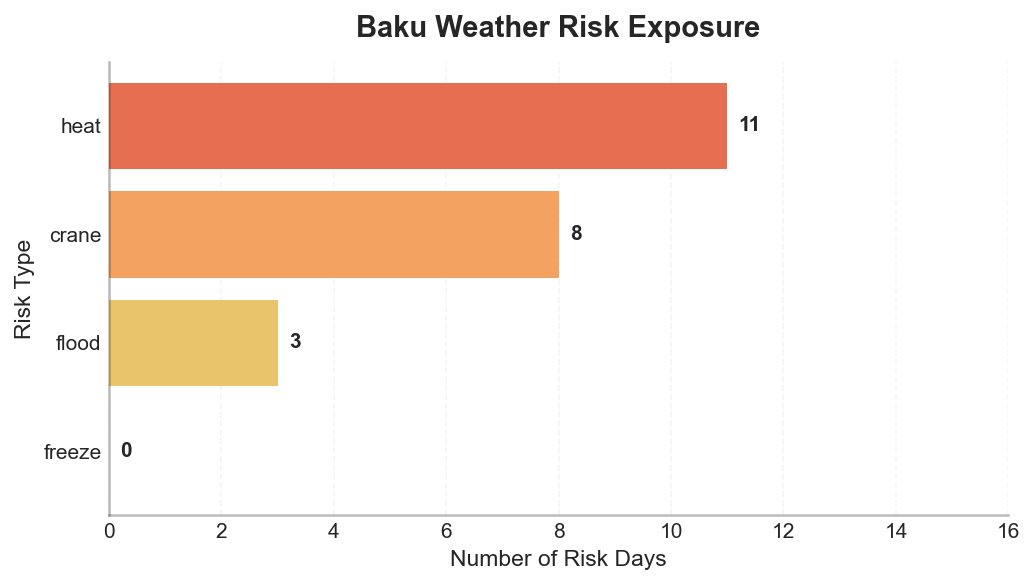

In [28]:
import matplotlib.pyplot as plt

baku_count = baku_count.sort_values('count', ascending=True)

plt.style.use('seaborn-v0_8-white')

fig, ax = plt.subplots(figsize=(7,4), dpi=150)

colors = ['#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']

bars = ax.barh(
    baku_count['risk'],
    baku_count['count'],
    color=colors,
    edgecolor='none'
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    'Baku Weather Risk Exposure',
    fontsize=14,
    fontweight='bold',
    pad=12
)

ax.set_xlabel('Number of Risk Days', fontsize=11)
ax.set_ylabel('Risk Type', fontsize=11)

# ✅ THIS IS WHAT YOU NEED
ax.set_xlim(0, 16)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_alpha(0.3)
ax.spines['bottom'].set_alpha(0.3)

ax.grid(axis='x', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

In [29]:
df.columns

Index(['date', 'city', 'day_number', 'crane_prob', 'freeze_prob', 'heat_prob',
       'flood_prob', 'total_risk', 'crane_alert', 'freeze_alert', 'heat_alert',
       'flood_alert', 'total_alert', 'crane_pct', 'freeze_pct', 'heat_pct',
       'flood_pct', 'total_risk_pct'],
      dtype='str')

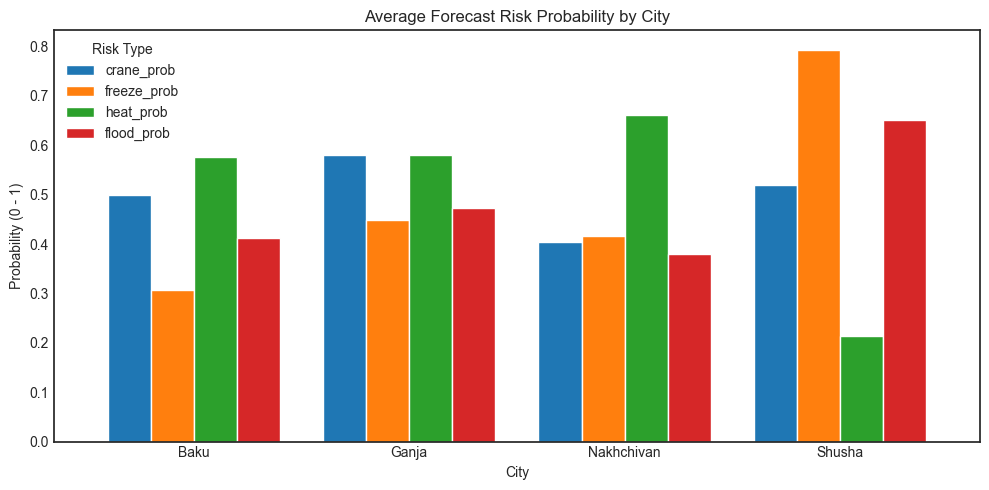

In [30]:
import matplotlib.pyplot as plt

# City-wise average probabilities
summary = df.groupby('city')[[
    'crane_prob',
    'freeze_prob',
    'heat_prob',
    'flood_prob'
]].mean().reset_index()

# Plot
ax = summary.set_index('city').plot(
    kind='bar',
    figsize=(10,5),
    width=0.8
)

ax.set_title('Average Forecast Risk Probability by City')
ax.set_ylabel('Probability (0 - 1)')
ax.set_xlabel('City')
plt.xticks(rotation=0)
plt.legend(title='Risk Type')

plt.tight_layout()
plt.show()